In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [93]:
data = pd.read_csv('finall_mwrged_full_data.csv')

In [94]:
data.columns

Index(['Unnamed: 0', 'Work code', 'order noumber', 'Repair date',
       'Machine names_x', 'Main system', 'Machine code', 'sub system',
       'Repairman', 'Type of work', 'تعمیرات2.6 الی 3.8', '-', 'price',
       'start', 'finish', 'قیمت دستور کار مهر', 'start-g', 'finish-g',
       'duration', 'year', 'month', 'year_month_greg', 'year_month_jalali',
       'quarter', 'CompanyName', 'Unnamed: 1', 'Category', 'Res1',
       'MobileNumber', 'UnitGroup', 'Unnamed: 6', 'RepairHourlyPrice', 'Id',
       'Unnamed: 9', 'Status', 'UnitName', 'LastWorkValue', 'Unnamed: 13',
       'DriverName', 'GPS Code_perf', 'Section', 'Unnamed: 17', 'VINNumber',
       'MotorNumber', 'DAMNumber', 'BodyNumber', 'PlakNumber_perf',
       'Unnamed: 23', 'Unnamed: 24', 'CarColour', 'BuildDate', 'EstateNo',
       'Unnamed: 29', 'Unnamed: 30', 'CarType', 'CarGroup_perf',
       'Machine names_y', 'Total Absolute Road Length (km)',
       '% of Main Roads (Arterial Roads)', '% of Freeways (Motorways)',
       

### mileage handling

In [95]:
data['MBF'] =data.groupby(["Machine code", "year_month_jalali"])["Mileage between failuers"].transform("max")

In [96]:
print(len(data[data['Mileage between failuers'] == 0]))
print(len(data[data['MBF'] == 0]))

306270
114464


In [97]:
data = data[data['MBF'] > 1]

In [98]:
# data = data[data['CarGroup_perf']!= 'سنگین']

In [99]:
initial_features = [
    # 'Repair date', 
    'Machine names_x',
    'Type of work',
    # 'year_month_jalali',
    'quarter',
    'CompanyName',
    'Category',
    'Weather Type',
    'Section',
    'BuildDate',
    'CarType',
    #'Road_Profile_Cluster',
    'Average speed',
    'Maximum speed',
    'Travel time',
    'Repairman',
    'Main system',
    # 'UnitName',
    'CarGroup_perf',
    'Road_Profile1_Cluster',
       'Topographic_Features_Cluster', 'Height_level_Cluster'
]

location_features = [
    'Total Absolute Road Length (km)',
    '% of Main Roads (Arterial Roads)',
    '% of Freeways (Motorways)',
    '% of Highways (Expressways)',
    '% of Minor Roads (Secondary Roads)',
            '% of Rural Roads',
        '% of Transit Roads',
        '% of Tunnel Length',
        '% of Bridge Length',
        'Road Length by Region',
    '% of Road in Plains (Flat Terrain)',
    '% of Length in Mountainous Terrain',
    'Length of Road in Rolling Terrain (Hilly)%',
                'Weather Type',
    'Road Length at Altitude < 500',
    '% of Road Length at Altitude 500 to 1000',
    '% of Road Length at Altitude 1000 to 1500',
    '% of Road Length at Altitude 1500 to 2000',
    '% of Road Length at Altitude 2000 to 2500',
    '% of Road Length at Altitude 2500 to [3000]',
    '% of Road Length at Altitude > [3000]',
    'Total Route Length based on Elevation Level',
    'Saturation Flow Adjustment Factors',
            'UnitGroup_road',

]

features = initial_features

Targets = [
    'price',
    'duration',
    'Main system',
    'Mileage between failuers'
]

In [100]:
columns = features + Targets

In [101]:
df = data[columns]
df.tail()

,Machine names_x,Type of work,quarter,CompanyName,Category,Weather Type,Section,BuildDate,CarType,Average speed,Maximum speed,Travel time,Repairman,Main system,CarGroup_perf,Road_Profile1_Cluster,Topographic_Features_Cluster,Height_level_Cluster,price,duration,Main system,Mileage between failuers
378126,لودر هپکو L90,تعمیر,1,هپکو,عملیات راهداری,گرم و مرطوب,NaN,1360,لودر,4.92,119.0,0,ابراهیم جهانگیرلو ت,سیستم برق والکترونیک,سنگین,0,0,0,148090000,5.0,سیستم برق والکترونیک,132.476
378128,بیل مکانیکی هپکو 912,پرس شیلنگ,4,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,30.37,111.0,0,حسینی,سیستم هیدرولیک,سنگین,8,4,4,1402/10/24,NaN,سیستم هیدرولیک,0.000
378129,بیل مکانیکی هپکو 912,پرس شیلنگ,4,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,30.37,111.0,0,حسینی,سیستم هیدرولیک,سنگین,8,4,4,1402/10/24,NaN,سیستم هیدرولیک,0.000
378130,بیل مکانیکی هپکو 912,پرس شیلنگ,4,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,30.37,111.0,0,حسینی,سیستم هیدرولیک,سنگین,8,4,4,1402/10/24,NaN,سیستم هیدرولیک,0.000
378131,بیل مکانیکی هپکو 912,پرس شیلنگ,4,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,30.37,111.0,0,حسینی,سیستم هیدرولیک,سنگین,8,4,4,1402/10/24,NaN,سیستم هیدرولیک,842.324


### Encoding

In [102]:
from sklearn.preprocessing import OrdinalEncoder
categorlal_features = ['Machine names_x', 
                       'Type of work', 
                       'CompanyName', 'Category', 
                       'Weather Type', 'Section', 
                       'CarType', 'Main system', 
                       'UnitName', 'CarGroup_perf', 'Repairman']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. Transform the data
data[categorlal_features] = encoder.fit_transform(data[categorlal_features].astype(str))

### 1.Random Forest

In [110]:
data['MBF'].quantile([0, 0.33, 0.66])

0.00       1.00100
0.33     706.79166
0.66    3106.65600
Name: MBF, dtype: float64

In [111]:
data['MBF_category'] = pd.qcut(data['MBF'], q=3, labels=[0, 1, 2])
# 1. Define Features (X) and Target (y)
# Ensure you use the 'Failure_Class' we created earlier (0, 1, 2)
X = data[features]
y = data['MBF_category']

# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
model = model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12,         # Stops trees from becoming infinitely deep
    min_samples_leaf=10,  # Prevents the model from creating rules for single data points
    max_samples=0.8,      # Each tree only sees 80% of the data (increases diversity)
    n_jobs=-1,            # Uses all your CPU cores
    random_state=42
)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Validation Metrics ---
Accuracy Score: 70.19%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79     17131
           1       0.58      0.62      0.60     17133
           2       0.72      0.73      0.73     17128

    accuracy                           0.70     51392
   macro avg       0.71      0.70      0.70     51392
weighted avg       0.71      0.70      0.70     51392



In [104]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = model.predict(X_train)

# Calculate scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")
print(f"Gap: {train_acc - test_acc:.2%}")

Training Accuracy: 71.29%
Testing Accuracy: 70.19%
Gap: 1.10%


In [106]:
def learning_curve(model):
    import matplotlib.pyplot as plt
    from sklearn.metrics import accuracy_score

    # 1. Reduce the dataset size for the plot if needed (e.g., use 20k samples total)
    # 2. Define specific training sizes to test
    subset_sizes = np.linspace(500, len(X_train), 5).astype(int)
    train_accs = []
    test_accs = []

    for size in subset_sizes:
        # Train on a small slice of the training data
        model.fit(X_train[:size], y_train[:size])
        
        # Record accuracy
        train_accs.append(accuracy_score(y_train[:size], model.predict(X_train[:size])))
        test_accs.append(accuracy_score(y_test, model.predict(X_test)))

    # Plotting the results
    plt.figure(figsize=(10, 5))
    plt.plot(subset_sizes, train_accs, 'o-', color="r", label="Training score")
    plt.plot(subset_sizes, test_accs, 'o-', color="g", label="Test score")
    plt.title("Fast Learning Curve (Accuracy vs Training Size)")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()
    return plt

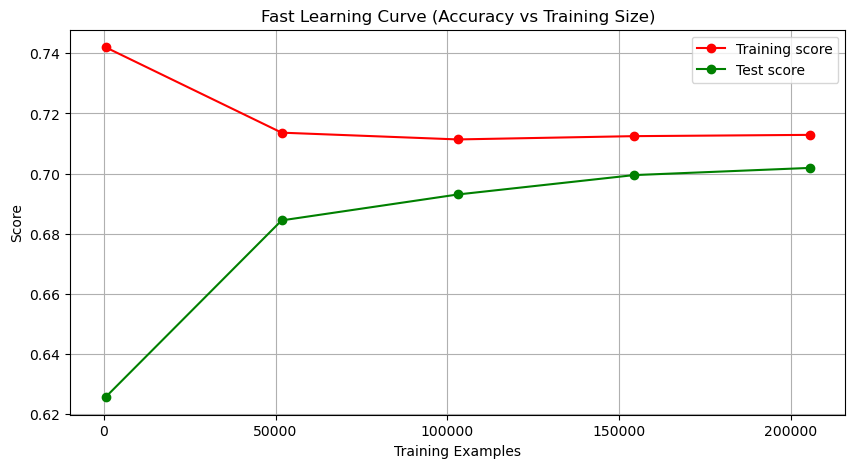

<module 'matplotlib.pyplot' from '/Users/aaa/opt/anaconda3/lib/python3.9/site-packages/matplotlib/pyplot.py'>

In [107]:
learning_curve(model=model)

#### XGboost

In [114]:
from xgboost import XGBClassifier
data['MBF_category'] = pd.qcut(data['MBF'], q=3, labels=[0, 1, 2])
# 1. Define Features (X) and Target (y)
# Ensure you use the 'Failure_Class' we created earlier (0, 1, 2)
X = data[features]
y = data['MBF_category']

# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
xgb_model = XGBClassifier(
    n_estimators=1000,        # Increased, but early_stopping will find the real limit
    learning_rate=0.05,
    max_depth=4,              # REDUCED: Prevents trees from being too complex
    subsample=0.8,           # NEW: Only uses 80% of rows per tree
    colsample_bytree=0.8,     # NEW: Only uses 80% of features per tree
    gamma=1,                 # NEW: Minimum loss reduction required for a split
    tree_method='hist',
    random_state=42,
)

xgb_model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = xgb_model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Validation Metrics ---
Accuracy Score: 69.67%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79     17131
           1       0.58      0.59      0.59     17133
           2       0.70      0.73      0.72     17128

    accuracy                           0.70     51392
   macro avg       0.70      0.70      0.70     51392
weighted avg       0.70      0.70      0.70     51392



In [115]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = xgb_model.predict(X_train)

# Calculate scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")
print(f"Gap: {train_acc - test_acc:.2%}")

Training Accuracy: 70.59%
Testing Accuracy: 69.67%
Gap: 0.92%


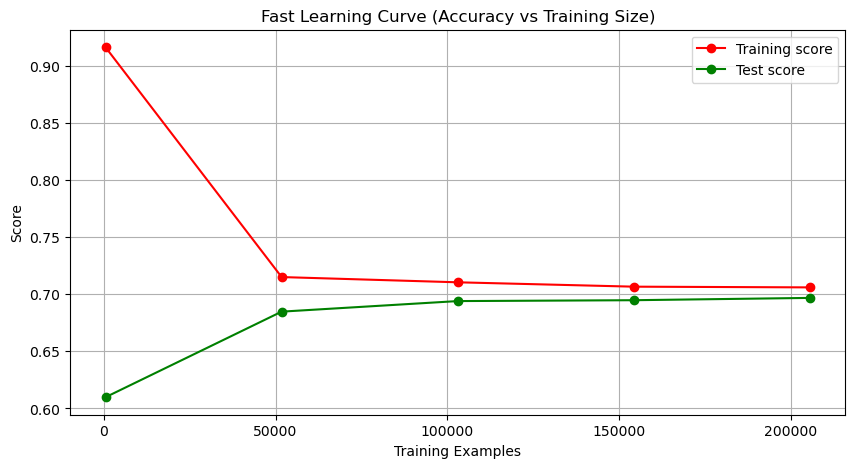

<module 'matplotlib.pyplot' from '/Users/aaa/opt/anaconda3/lib/python3.9/site-packages/matplotlib/pyplot.py'>

In [116]:
learning_curve(model=xgb_model)

### aproaches for calculate the optimal k for quntile cuts

In [120]:
import numpy as np

# Calculate IQR and n
q75, q25 = np.percentile(data['MBF'], [75 ,25])
iqr = q75 - q25
n = len(data['MBF'])

# Calculate bin width and number of bins
bin_width = 2 * iqr / (n ** (1/3))
optimal_q = int((data['MBF'].max() - data['MBF'].min()) / bin_width)

print(f"Statistically suggested q: {optimal_q}")

Statistically suggested q: 2173


In [119]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test different k values on a sample of your data (for speed)
sample_mbf = data['MBF'].sample(10000).values.reshape(-1, 1)
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(sample_mbf)
    score = silhouette_score(sample_mbf, kmeans.labels_)
    print(f"k={k}, Silhouette Score: {score:.4f}")

k=2, Silhouette Score: 0.7847
k=3, Silhouette Score: 0.7294
k=4, Silhouette Score: 0.6893
k=5, Silhouette Score: 0.6593
k=6, Silhouette Score: 0.6341
k=7, Silhouette Score: 0.6179
k=8, Silhouette Score: 0.6186
k=9, Silhouette Score: 0.6144
